# Module 5 · Project — Knowledge Assistant v2 · SOLUTION

**From 0 to Agentic AI — DataHack Summit 2026**

🧩 **v2 — real tools.** We upgrade the assistant from toy tools to real external systems:
a custom **web search** (wrapping the Seltz API), and two **action** tools that draft a
**Slack** message and a **GitHub** issue. Same graph as v1 — richer hands.

> ✅ **Solution notebook** — full implementations shown.

### What you'll build
1. `web_search` — wrap the **Seltz** client as a `@tool` (connecting an external API)
2. `draft_slack_message` — build a Slack payload (**dry-run**, doesn't send)
3. `draft_github_issue` — build a GitHub issue payload (**dry-run**)
4. Bind all three into the v1 graph → **v2**, and drive it

### 🏗️ Architecture
```
  user ──▶ agent ──(tool call?)──▶ tools: web_search | slack | github
            ▲                              │
            └────────── observation ◀──────┘
```
Same reason→act→observe loop from Module 4; we're only changing the tools.

---
## Setup

In [1]:
# Install the workshop stack (Colab). Locally, use `uv sync` instead.
# Version ranges match src/pyproject.toml (the single source of truth).
!pip install -q "langchain>=1.2,<2" "langchain-openai>=1.1,<2" \
               "langgraph>=1.0,<2" "seltz>=1.5.0"

ERROR: Could not find a version that satisfies the requirement langchain<2,>=1.2 (from versions: 0.0.1, 0.0.2, 0.0.3, 0.0.4, 0.0.5, 0.0.6, 0.0.7, 0.0.8, 0.0.9, 0.0.10, 0.0.11, 0.0.12, 0.0.13, 0.0.14, 0.0.15, 0.0.16, 0.0.17, 0.0.18, 0.0.19, 0.0.20, 0.0.21, 0.0.22, 0.0.23, 0.0.24, 0.0.25, 0.0.26, 0.0.27, 0.0.28, 0.0.29, 0.0.30, 0.0.31, 0.0.32, 0.0.33, 0.0.34, 0.0.35, 0.0.36, 0.0.37, 0.0.38, 0.0.39, 0.0.40, 0.0.41, 0.0.42, 0.0.43, 0.0.44, 0.0.45, 0.0.46, 0.0.47, 0.0.48, 0.0.49, 0.0.50, 0.0.51, 0.0.52, 0.0.53, 0.0.54, 0.0.55, 0.0.56, 0.0.57, 0.0.58, 0.0.59, 0.0.60, 0.0.61, 0.0.63, 0.0.64, 0.0.65, 0.0.66, 0.0.67, 0.0.68, 0.0.69, 0.0.70, 0.0.71, 0.0.72, 0.0.73, 0.0.74, 0.0.75, 0.0.76, 0.0.77, 0.0.78, 0.0.79, 0.0.80, 0.0.81, 0.0.82, 0.0.83, 0.0.84, 0.0.85, 0.0.86, 0.0.87, 0.0.88, 0.0.89, 0.0.90, 0.0.91, 0.0.92, 0.0.93, 0.0.94, 0.0.95, 0.0.96, 0.0.97, 0.0.98, 0.0.99rc0, 0.0.99, 0.0.100, 0.0.101rc0, 0.0.101, 0.0.102rc0, 0.0.102, 0.0.103, 0.0.104, 0.0.105, 0.0.106, 0.0.107, 0.0.108, 0.0.109, 0.0

In [2]:
import os
from getpass import getpass

# Local: load keys from src/.env (walks up to find it). Colab: prompts for missing keys.
try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True))
except Exception:
    pass

for key in ["OPENAI_API_KEY", "SELTZ_API_KEY"]:
    if not os.environ.get(key):
        os.environ[key] = getpass(f"{key}: ")

---
## Tool 1 · Web search (wrapping the Seltz API)

This is the heart of *connecting an external API*: the Seltz client is a plain Python object;
we wrap a call to it in a `@tool` with a good docstring and a `try/except`.

**TODO:** finish `web_search` — call `client.search(query, max_results=...)`, then join the
returned `resp.documents` (each has `.url` and `.content`) into a readable string. Wrap it in
a `try/except` that returns a readable error.

In [3]:
from langchain_core.tools import tool
from seltz import Seltz

_seltz = Seltz()   # reads SELTZ_API_KEY from the environment

In [4]:
@tool
def web_search(query: str, max_results: int = 3) -> str:
    """Search the web for current, external information."""
    try:
        resp = _seltz.search(query, max_results=max_results)
    except Exception as e:
        return f"search error: {e}"
    docs = resp.documents
    if not docs:
        return "no results found"
    return "\n\n".join(f"{d.url}\n{(d.content or '')[:300]}" for d in docs)

In [5]:
print(web_search.invoke({"query": "What is LangGraph?"})[:300])

https://www.datacamp.com/tutorial/langgraph-studio
## What Is LangGraph Studio?

LangGraph Studio is a specialized Integrated Development Environment \(IDE\) designed for building AI agents, particularly those using the LangGraph framework\.

Unlike traditional IDEs that focus on general software de


---
## Tool 2 · Draft a Slack message (dry-run)

Our assistant can *act* — but safely. Rather than posting to Slack, this tool **returns the
message payload for review**. (Actually sending is a one-line `requests.post` to a Slack
webhook — left out so the workshop needs no tokens.)

**TODO:** return a JSON string with keys `action`, `channel`, `message`.

In [6]:
import json

@tool
def draft_slack_message(channel: str, message: str) -> str:
    """Draft a Slack message to a channel for review (does NOT send)."""
    return json.dumps({"action": "slack.draft", "channel": channel, "message": message}, indent=2)

---
## Tool 3 · Draft a GitHub issue (dry-run)

Same pattern — build the issue payload, don't create it.

**TODO:** return a JSON string with keys `action`, `repo`, `title`, `body`.

In [7]:
@tool
def draft_github_issue(repo: str, title: str, body: str) -> str:
    """Draft a GitHub issue for a repo for review (does NOT create it). repo is 'owner/name'."""
    return json.dumps({"action": "github.issue.draft", "repo": repo, "title": title, "body": body}, indent=2)

### Test the tools standalone
Always exercise a tool directly before handing it to the agent.

In [8]:
print(draft_slack_message.invoke({"channel": "#billing", "message": "Deploy is failing."}))
print()
print(draft_github_issue.invoke(
    {"repo": "acme/api", "title": "Deploy fails", "body": "The 3pm deploy failed."}))

{
  "action": "slack.draft",
  "channel": "#billing",
  "message": "Deploy is failing."
}

{
  "action": "github.issue.draft",
  "repo": "acme/api",
  "title": "Deploy fails",
  "body": "The 3pm deploy failed."
}


---
## Assemble v2

Same graph as v1 (Module 4) — we just pass the new tool list. This is why the graph
abstraction pays off: swapping capabilities doesn't touch the loop.

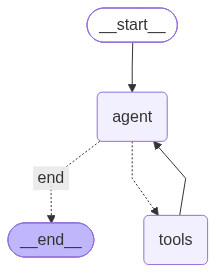

In [9]:
from typing import Annotated, TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

tools = [web_search, draft_slack_message, draft_github_issue]

SYSTEM_PROMPT = (
    "You are the Knowledge Assistant for a software company. "
    "Answer questions using web search when useful. When the user asks to notify "
    "someone or file an issue, draft it with the appropriate tool and show them the draft."
)

llm = init_chat_model("gpt-4.1-mini", model_provider="openai", temperature=0)
llm_with_tools = llm.bind_tools(tools)

class State(TypedDict):
    messages: Annotated[list, add_messages]

def call_model(state: State):
    msgs = [("system", SYSTEM_PROMPT)] + state["messages"]
    return {"messages": [llm_with_tools.invoke(msgs)]}

def should_continue(state: State) -> str:
    return "tools" if state["messages"][-1].tool_calls else "end"

builder = StateGraph(State)
builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
builder.add_edge("tools", "agent")
assistant = builder.compile()

display(Image(assistant.get_graph().draw_mermaid_png()))

---
## Run it

One question that needs **search**, and one that needs an **action** (a Slack draft).

In [10]:
def ask(q):
    out = assistant.invoke({"messages": [("user", q)]})
    return out["messages"][-1].content

print(ask("What is the latest major version of LangGraph?"))

The web search did not return specific information about the latest major version number of LangGraph. Would you like me to try a more specific search or check a particular source such as the official LangGraph repository or website?


In [11]:
out = assistant.invoke({"messages": [(
    "user", "The billing service deploy is failing — draft a Slack message to #billing.")]})
for m in out["messages"]:
    m.pretty_print()

================================ Human Message =================================

The billing service deploy is failing — draft a Slack message to #billing.
================================== Ai Message ==================================
Tool Calls:
  draft_slack_message (call_ZBLGh2b1SUJKEqcgS1p1qhBU)
 Call ID: call_ZBLGh2b1SUJKEqcgS1p1qhBU
  Args:
    channel: #billing
    message: Heads up team, the billing service deploy is currently failing. Could someone please investigate the issue? Let me know if you need any additional information from my side.
================================= Tool Message =================================
Name: draft_slack_message

{
  "action": "slack.draft",
  "channel": "#billing",
  "message": "Heads up team, the billing service deploy is currently failing. Could someone please investigate the issue? Let me know if you need any additional information from my side."
}
================================== Ai Message ==================================

I have

---
## Key takeaways
- **Wrapping an API as a `@tool`** is the core move for connecting external systems.
- **Draft / dry-run** action tools let an agent *act* safely — no tokens, review before send.
- Good **docstrings + try/except** make the difference between a reliable tool and a flaky one.
- Adding tools **didn't change the graph** — the Module 4 loop just gained new hands.

➡️ **Next (Module 6):** give the assistant real internal knowledge — **RAG**, context
engineering, and MCP — so it can answer about *your* docs, not just the web.